In [1]:
import yaml
import joblib 
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Any

# define project root
PROJECT_ROOT = Path().resolve().parent

# **Load Config**

In [2]:
# define load config function

config_path = PROJECT_ROOT/'config/config.yaml'

def load_config(config_path: str) -> dict:
    """

    Load the configuration file.

    Parameters:
    -----------
    config_path (str): The path to the configuration file.

    Returns:
    --------
    config (dict): The loaded configuration as a dictionary.

    """
    try:
        with open(config_path, 'r') as file:
            config = yaml.safe_load(file)
        if config is None:
            raise ValueError("Configuration file is empty.")
        
    except FileNotFoundError:
        raise FileNotFoundError(f"Configuration file not found at: {config_path}")
    
    except yaml.YAMLError as e:
        raise ValueError(f"Error parsing YAML file: {e}")
    
    return config

In [3]:
# load config
config = load_config(config_path=config_path)
config

{'ALL_COLS': ['Age',
  'Attrition',
  'BusinessTravel',
  'DailyRate',
  'Department',
  'DistanceFromHome',
  'Education',
  'EducationField',
  'EnvironmentSatisfaction',
  'Gender',
  'HourlyRate',
  'JobInvolvement',
  'JobLevel',
  'JobRole',
  'JobSatisfaction',
  'MaritalStatus',
  'MonthlyIncome',
  'MonthlyRate',
  'NumCompaniesWorked',
  'OverTime',
  'PercentSalaryHike',
  'PerformanceRating',
  'RelationshipSatisfaction',
  'StockOptionLevel',
  'TotalWorkingYears',
  'TrainingTimesLastYear',
  'WorkLifeBalance',
  'YearsAtCompany',
  'YearsInCurrentRole',
  'YearsSinceLastPromotion',
  'YearsWithCurrManager'],
 'BEST_THRESHOLD_POINT': 0.45,
 'CAT_COLS': ['BusinessTravel',
  'Department',
  'Education',
  'EducationField',
  'Gender',
  'JobRole',
  'MaritalStatus',
  'OverTime'],
 'NUM_COLS': ['Age',
  'DailyRate',
  'DistanceFromHome',
  'EnvironmentSatisfaction',
  'HourlyRate',
  'JobInvolvement',
  'JobLevel',
  'JobSatisfaction',
  'MonthlyIncome',
  'MonthlyRate',
  

# **Load Train Set**

In [4]:
# define deserialize object function
def deserialize_object(path: str) -> Any:
    """
    Deserialize the object into specified path.

    Parameters:
    -----------
    path (str) : The path to deserialize the object.

    Returns:
    --------
    object (Any) : Any object will be deserialized.
    """

    obj = joblib.load(path)
    return obj

In [5]:
# load X_train and y_train
X_train = deserialize_object(path=PROJECT_ROOT/'data'/'interim'/'X_train.pkl')
y_train = deserialize_object(path=PROJECT_ROOT/'data'/'interim'/'y_train.pkl')

In [6]:
# check X_train head
X_train.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1194,47,Travel_Rarely,1225,Sales,2,Master,Life Sciences,2,Female,47,...,3,3,3,29,2,3,3,2,1,2
128,22,Travel_Rarely,594,Research & Development,2,Below College,Technical Degree,3,Male,100,...,3,3,1,3,2,3,2,1,2,1
810,46,Travel_Rarely,406,Sales,3,Below College,Marketing,1,Male,52,...,3,4,1,23,3,3,12,9,4,9
478,25,Travel_Rarely,622,Sales,13,Below College,Medical,2,Male,40,...,3,3,0,7,1,3,7,4,0,6
491,43,Travel_Frequently,1001,Research & Development,9,Doctor,Medical,4,Male,72,...,3,2,1,10,3,3,8,7,4,7


In [7]:
# check y_train head
y_train.head()

1194    0
128     0
810     0
478     0
491     0
Name: Attrition, dtype: int64

In [8]:
# concat X_train and y_train for EDA purposes
train_data = pd.concat([X_train, y_train], axis=1)
train_data.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
1194,47,Travel_Rarely,1225,Sales,2,Master,Life Sciences,2,Female,47,...,3,3,29,2,3,3,2,1,2,0
128,22,Travel_Rarely,594,Research & Development,2,Below College,Technical Degree,3,Male,100,...,3,1,3,2,3,2,1,2,1,0
810,46,Travel_Rarely,406,Sales,3,Below College,Marketing,1,Male,52,...,4,1,23,3,3,12,9,4,9,0
478,25,Travel_Rarely,622,Sales,13,Below College,Medical,2,Male,40,...,3,0,7,1,3,7,4,0,6,0
491,43,Travel_Frequently,1001,Research & Development,9,Doctor,Medical,4,Male,72,...,2,1,10,3,3,8,7,4,7,0


# **Exploratory Data Analysis**

In [9]:
# missing value check
train_data.isna().sum()

Age                         0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
Attrition                   0
dtype: int64

In [10]:
# check descriptive statistics of the data
train_data.describe()

,Age,DailyRate,DistanceFromHome,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
count,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,...,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000
mean,36.998299,803.991497,9.357993,2.716837,65.500000,2.737245,2.076531,2.719388,6544.024660,14390.239796,...,2.738946,0.790816,11.364796,2.760204,2.757653,7.050170,4.231293,2.182823,4.196429,0.161565
std,9.178142,401.339423,8.179803,1.088707,20.373324,0.703673,1.091987,1.110644,4653.743955,7192.834394,...,1.087201,0.845786,7.801391,1.256262,0.718113,6.086612,3.569503,3.215348,3.564795,0.368208
min,18.000000,103.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,467.750000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,2948.000000,8051.000000,...,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,0.000000
50%,36.000000,799.500000,7.000000,3.000000,66.000000,3.000000,2.000000,3.000000,5004.500000,14373.000000,...,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,0.000000
75%,43.000000,1157.000000,14.000000,4.000000,83.000000,3.000000,3.000000,4.000000,8420.500000,20770.750000,...,4.000000,1.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,0.000000
max,60.000000,1499.000000,29.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19973.000000,26999.000000,...,4.000000,3.000000,40.000000,6.000000,4.000000,37.000000,17.000000,15.000000,17.000000,1.000000


Actually, there is no obvious outlier on each column. From the numbers of quartile 3 (75%) and maximum data, it has already aligned with the business context. For example, we can see there is a big gap on YearsAtCompany between the 75% data and the maximum data, which are 10 and 37 years. But, if we see the deeper context, it makes really sense that numbers show the loyalty level of each employee. There is always the possibility of employee's career timeline reaching more than 30 years.

In [11]:
# skewness check on numerical data
skewness = train_data.skew(numeric_only=True)

# filter column containing skewness > 1 or < -1
high_skewness = skewness[(skewness > 1) | (skewness < -1)]
high_skewness

MonthlyIncome              1.332950
PerformanceRating          1.884807
TotalWorkingYears          1.103707
YearsAtCompany             1.732897
YearsSinceLastPromotion    1.970864
Attrition                  1.841418
dtype: float64

In [12]:
len(config['NUM_COLS'])

22

I consider the skewness that has potential to disrupt the ML model building is in the range of > 1 and < -1. I think it is suite to describe as a moderate skew. All of those 5 columns, they are all skewed right distribution. But, before taking any action to treat the skewness, we have to see the business context behind them.

- Monthly Income => It has always been a little number of employee having huge amount of salary, majority of salary numbers are distributed into the lower-middle range.
- Performance Rating => If we take a look on descriptive analytics, we know that the minimum performance rating given to all the employee is in the range between 3 and 4. So, it is obvious that the distribution will be hardly right-skewed.
- It also can be applied on the rest of the high skewness columns, each of them has their own business context. So, I decide that I won't be dropping any of those column.

I believe that the skewness distributon won't be a concerning issue since I won't be using any linear model in the future. However, I will be focusing to use boosting tree-based models with their robust capacity towards the skewed distribution.

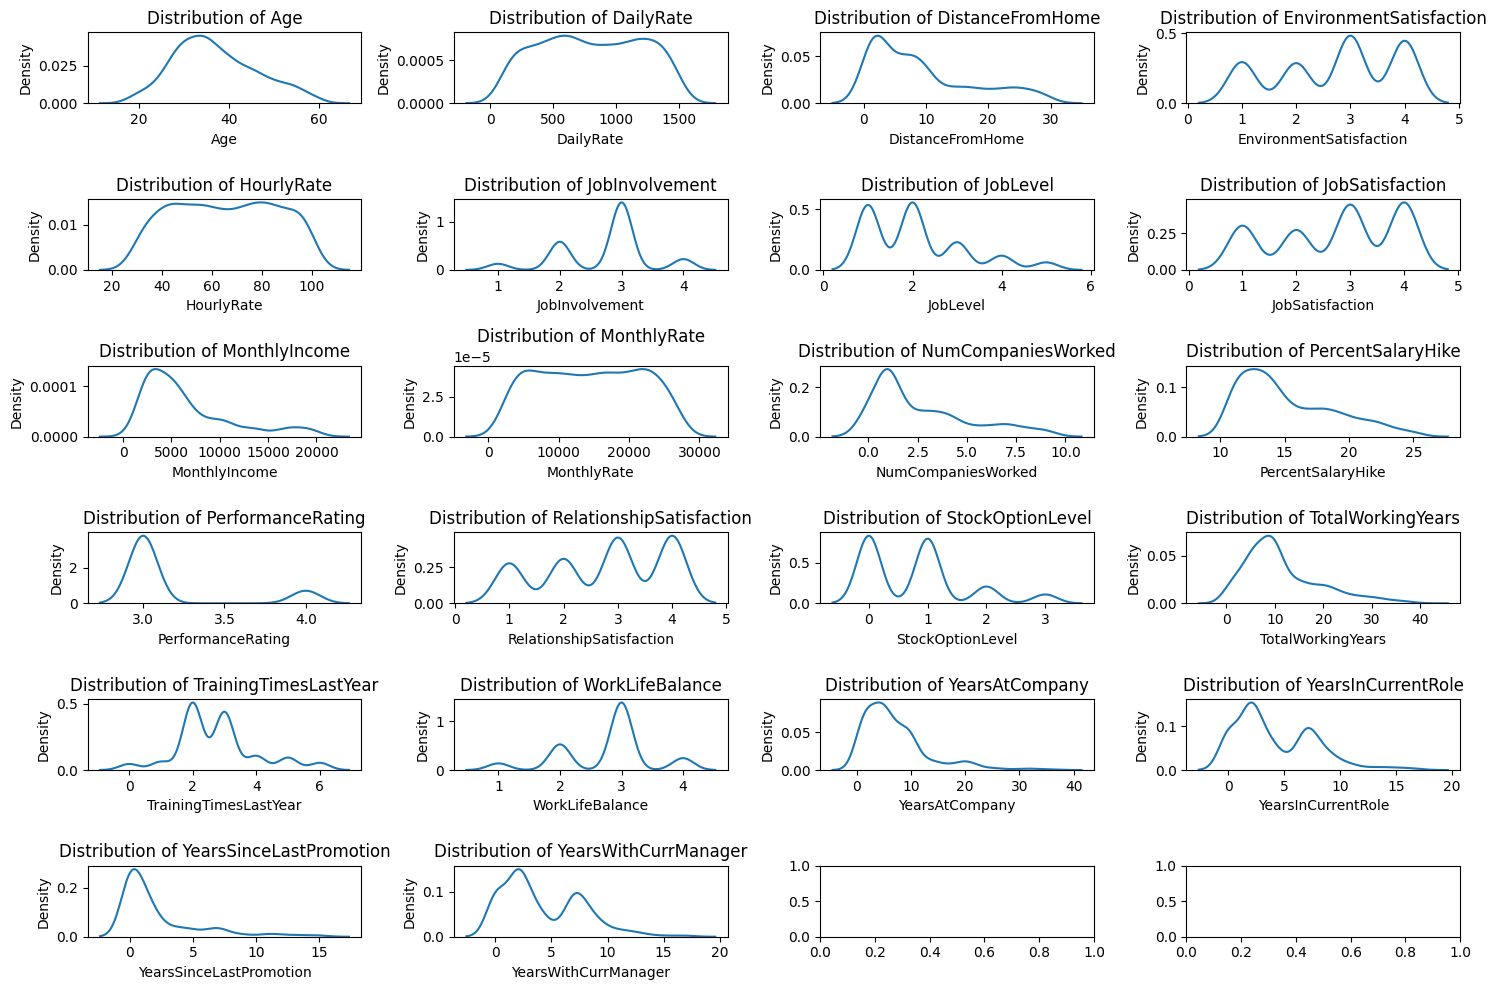

In [13]:
# check all numerical columns distribution
fig, ax = plt.subplots(nrows=6, ncols=4, figsize=(15,10))
ax = ax.flatten()

for i, col in enumerate(config['NUM_COLS']):
    sns.kdeplot(data=train_data, x=col, ax=ax[i])
    ax[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

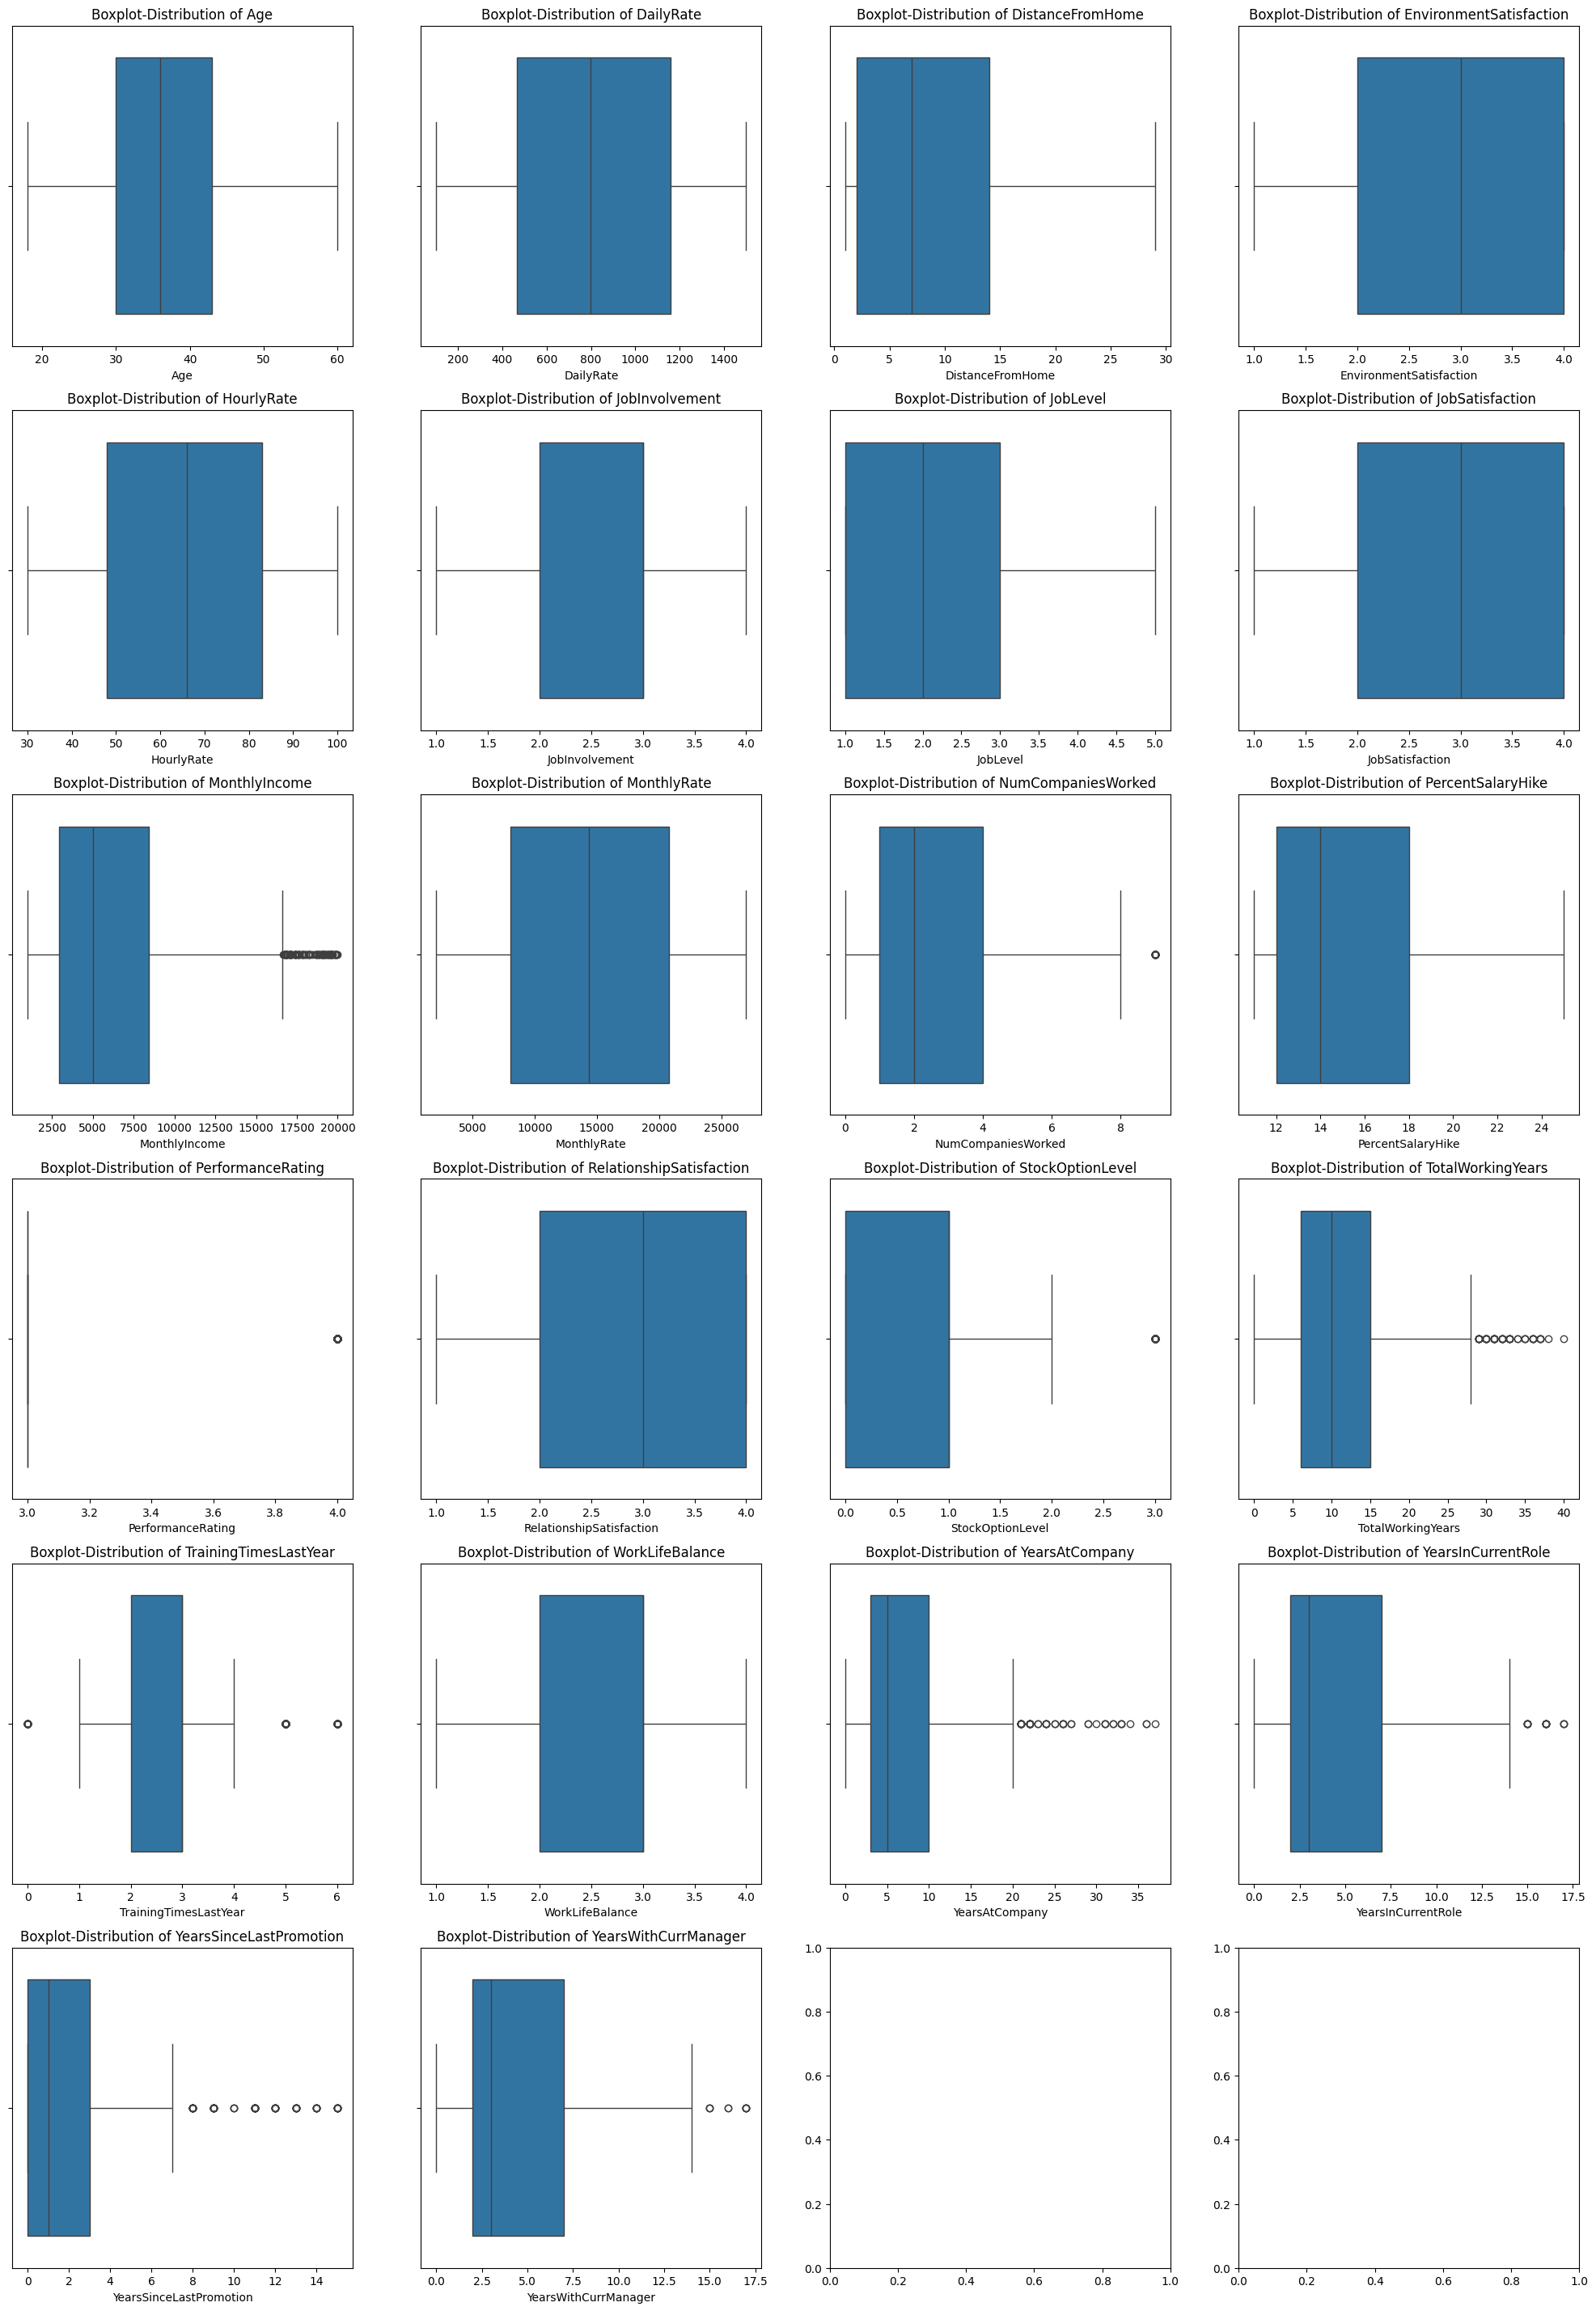

In [14]:
# make a sub-boxplots distribution
fig, ax = plt.subplots(nrows=6, ncols=4, figsize=(25,36))
axes = ax.flatten()

for i, col in enumerate(config['NUM_COLS']):
    sns.boxplot(data=train_data, x=col, ax=axes[i])
    axes[i].set_title(f'Boxplot-Distribution of {col}')

plt.show()

As already stated from the skewness explanation, there is actually some outlier point from several numeric columns, but it is still align with the business context and the range of minimum and maximum value isn't show any indication of anomaly numbers. So, I won't be doing any action to drop the potential outliers.

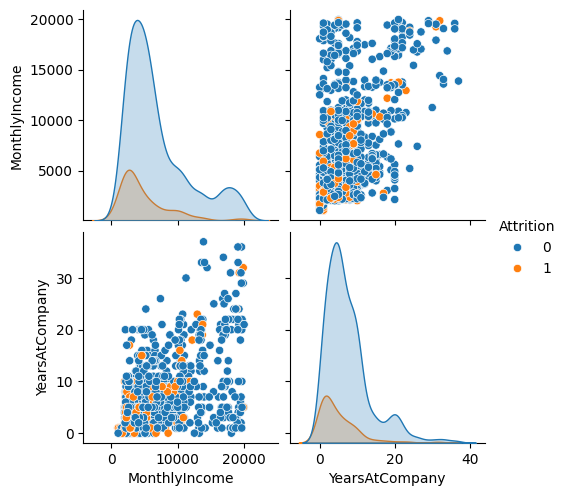

In [15]:
# check whether the features are linearly separated or non-linear
sns.pairplot(
    train_data[['MonthlyIncome', 'YearsAtCompany', 'Attrition']],
    hue='Attrition'
)

After picking one sample of relationship between 2 features with attrition as the hue, it shows that monthly income and yearsatcompany are not linearly separated based on the attrition. It should be applied the same for other features so this is become the first reason why the boosting tree based models are more suitable to generalize the complexity of non-linear model. But, let's see the other analysis to strengthen the reason

In [16]:
train_data.groupby(
    pd.cut(train_data['MonthlyIncome'], bins=5))['Attrition'].mean()

/tmp/ipykernel_130353/3426345215.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_data.groupby(


MonthlyIncome
(990.036, 4801.8]     0.219820
(4801.8, 8594.6]      0.117470
(8594.6, 12387.4]     0.148148
(12387.4, 16180.2]    0.084746
(16180.2, 19973.0]    0.042105
Name: Attrition, dtype: float64

From the probability of attrition based on their monthly income shows the numbers are not gradually increased or decreased. It shows the data on certain point would be increased or decreased based on their income, so it is clearly state the data is not linearly separated. From this EDA phase, modeling phase will be using the tree based boosting model to make the generalization of employee attrition prediction model.

In [17]:
# check label target distribution
train_data['Attrition'].value_counts(normalize=True)

Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64

The label target is indicated as the imbalance proportion because the distribution is overly distributed into negative class (No) with 83.84% over the positive class.